# **<center>09_eval_exp02_station_effect_distribution_shift</center>**

### Table of Contents

1. **Notebook Overview**  
   - Objective of Experiment 2: assessment of the impact of workstation–dependent image processing  
   - Evaluation of domain shift induced by different radiographic workstations (CZC vs RAD)  
   - Role of this experiment within the overall experimental pipeline  

2. **Environment Setup**  
   - Import of required libraries and utility functions  

3. **Loading Test Images and Metadata**  
   - 3.1. Loading of test images for each workstation   
   - 3.2. Loading of metadata and alignment of labels with image arrays

4. **Loading Trained CNN Models**  
   - Loading of the CNN trained on CZC images  
   - Loading of the CNN trained on RAD images  
   - Loading of the CNN trained on combined CZC + RAD data  
   - Inspection of model architectures and consistency checks  

5. **Model Evaluation on Cross-Domain Test Sets**  
   - 5.1. Evaluation of each model on the CZC and RAD test set  
     - Confusion matrix and classification metrics  
     - ROC curve, AUC and analytical confidence intervals  
     - Saving of per-model metrics and ROC curves  
   - 5.2. Statistical Comparison Between Models  
     - Paired comparison of ROC AUC using the DeLong test  
     - Paired comparison of classification errors using McNemar’s test   

6. **Model Explainability**  
    - Explainability of CNN predictions using Grad-CAM  
    - Generation of Grad-CAM heatmaps for CZC and RAD test images  

7. **Summary and Conclusions**  
   - Impact of workstation-induced domain shift on CNN generalization  
   - Quantitative evidence of improved robustness with multi-domain training  
   - Clinical and methodological implications for dataset design in medical imaging AI  


### **1. Notebook Overview**

In Experiment 2 we evaluate the impact of workstation-dependent image processing on the generalization ability of convolutional neural networks for the detection of calcifying tendinopathy in shoulder radiographs. Although all images originate from the same institution and clinical workflow, they are processed by different workstation systems (CZC and RAD), which introduce subtle but relevant textural differences. The objective of this experiment is to assess whether these technical variations induce a distribution shift that affects model performance when applied to unseen workstation domains.

Three training strategies are compared: a model trained exclusively on images processed by the CZC workstation, a model trained exclusively on RAD-processed images, and a combined model trained on data from both workstations (CZC+RAD). Each model is evaluated on both test domains, enabling a systematic analysis of within-domain performance and cross-domain generalization. This experimental design isolates the effect of workstation-related texture differences while keeping anatomical region, pathology definition, and institutional context constant.

From a clinical and methodological perspective, this experiment addresses a critical but often overlooked source of variability in medical imaging pipelines. In real-world scenarios, radiographs may be processed by different workstations even within the same hospital, and models deployed in such environments must remain robust to these technical shifts. Experiment 2 therefore aims to quantify the magnitude of this effect and to explore whether multi-domain training can mitigate workstation-induced performance degradation.


### **2. Environment Setup**

In [1]:
# System utilities
import os
from datetime import datetime
from tqdm import tqdm
import ast

# NumPy & Pandas
import numpy as np
import pandas as pd

# Image processing & visualization
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from IPython.display import Image, display

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model

# Scikit-learn metrics
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from scipy.stats import norm

2026-02-05 16:28:45.806527: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-05 16:28:46.526983: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


### **3. Load Images and Metadata**

#### **3.1. Load images**

In [2]:
# === Definition of test subsets (by workstation domain) ===
subset_test_RAD = "TC_RAD_test"
subset_test_CZC = "TC_CZC_test"

# === Base path to the cropped test subsets ===
subsets_path = "Subsets/"

# === Build full paths to test images ===
subset_test_path_RAD = os.path.join(subsets_path, subset_test_RAD)
subset_test_path_CZC = os.path.join(subsets_path, subset_test_CZC)

images_test_path_RAD = [
    os.path.join(subset_test_path_RAD, fname)
    for fname in os.listdir(subset_test_path_RAD)
    if fname.endswith(".npy")
]

images_test_path_CZC = [
    os.path.join(subset_test_path_CZC, fname)
    for fname in os.listdir(subset_test_path_CZC)
    if fname.endswith(".npy")
]

# === Summary ===
print(f"Number of images in RAD test subset: {len(images_test_path_RAD)}")
print(f"Number of images in CZC test subset: {len(images_test_path_CZC)}")


Number of images in RAD test subset: 200
Number of images in CZC test subset: 196


In [3]:
# Load images
def load_images(images_path):
    X_list = []

    for image_path in tqdm(images_path, desc='📥 Cargando imágenes'):
        try:
            X_ = np.load(image_path)
            X_list.append(X_)
        except Exception as e:
            print(f'⚠️ Error al cargar {image_path}: {e}')

    X = np.array(X_list)
    return X

In [4]:
# Load test images
X_test_RAD = load_images(images_test_path_RAD)
X_test_CZC = load_images(images_test_path_CZC)

# Display array shapes
print(f"X_test_RAD shape: {X_test_RAD.shape}")
print(f"X_test_CZC shape: {X_test_CZC.shape}")


📥 Cargando imágenes: 100%|███████████████████| 196/196 [00:11<00:00, 17.39it/s]

X_test_RAD shape: (200, 300, 300, 3)
X_test_CZC shape: (196, 300, 300, 3)


#### **3.2. Load metadata**

In [5]:
# Load metadata for RAD and CZC test sets
df_test_RAD = pd.read_csv(
    os.path.join(subsets_path, f"{subset_test_RAD}.cropped.csv")
)
df_test_CZC = pd.read_csv(
    os.path.join(subsets_path, f"{subset_test_CZC}.cropped.csv")
)

# Display number of rows
print(f"Rows in RAD test set: {df_test_RAD.shape}")
print(f"Rows in CZC test set: {df_test_CZC.shape}")


Rows in RAD test set: (200, 20)
Rows in CZC test set: (196, 20)


In [6]:
def extract_labels(df, images_path):
    # Build mapping: rx_cod -> label
    label_dict = dict(zip(df["rx_cod"], df["label_CalTend"]))

    # Extract labels based on filename (without extension)
    y = np.array([
        label_dict[os.path.splitext(os.path.basename(path))[0]]
        for path in images_path
    ])

    return y


In [7]:
# Extract labels aligned with test images
y_test_RAD = extract_labels(df_test_RAD, images_test_path_RAD)
y_test_CZC = extract_labels(df_test_CZC, images_test_path_CZC)

# Display label array shapes
print(f"y_test_RAD shape: {y_test_RAD.shape}")
print(f"y_test_CZC shape: {y_test_CZC.shape}")


y_test_RAD shape: (200,)
y_test_CZC shape: (196,)


### **4. Load models**

In [8]:
# Paths to the best CNN models CZC, RAD y CZC_RAD
model_path_CZC      = 'Models/TC_CZC.h5'
model_path_RAD      = 'Models/TC_RAD.h5'
model_path_CZC_RAD  = 'Models/TC_CZC_RAD.h5'

# Load models
model_CZC     = load_model(model_path_CZC)
model_RAD     = load_model(model_path_RAD)
model_CZC_RAD = load_model(model_path_CZC_RAD)

# Display model summaries
print("Model trained on CZC data:")
model_CZC.summary()

print("\nModel trained on RAD data:")
model_RAD.summary()

print("\nModel trained on CZC + RAD data:")
model_CZC_RAD.summary()


2026-02-05 16:30:21.717453: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-05 16:30:21.783673: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-05 16:30:21.786858: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Model trained on CZC data:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 9, 9, 512)         20024384  
                                                                 
 global_max_pooling2d (Glob  (None, 512)               0         
 alMaxPooling2D)                                                 
                                                                 
 dense (Dense)               (None, 1)                 513       
                                                                 
Total params: 20024897 (76.39 MB)
Trainable params: 20024897 (76.39 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

Model trained on RAD data:
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vg

### **5. Models Evaluation Workstation shift (CZC vs RAD)**

#### **5.1. Model evaluation on the test subsets**


=== Evaluation: CZC_model on CZC_test ===


2026-02-05 16:34:12.039737: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600


7/7 [==============================] - 10s 426ms/step
Confusion matrix:
[[86 12]
 [31 67]]

cut_off_threshold_point: 0.7427999973297119
Sensitivity: 0.6837
Specificity: 0.8776
PPV: 0.8481
NPV: 0.735
F1 score: 0.7571
Accuracy: 0.7806
ROC AUC: 0.8309
CI 90%: [0.7826 – 0.8793]
CI 95%: [0.7733 – 0.8885]
CI 99%: [0.7552 – 0.9066]

=== Evaluation: CZC_model on RAD_test ===
7/7 [==============================] - 4s 606ms/step
Confusion matrix:
[[90 10]
 [40 60]]

cut_off_threshold_point: 0.8967000246047974
Sensitivity: 0.6
Specificity: 0.9
PPV: 0.8571
NPV: 0.6923
F1 score: 0.7059
Accuracy: 0.75
ROC AUC: 0.8085
CI 90%: [0.7579 – 0.8591]
CI 95%: [0.7482 – 0.8688]
CI 99%: [0.7292 – 0.8878]

=== Evaluation: RAD_model on CZC_test ===
7/7 [==============================] - 2s 269ms/step
Confusion matrix:
[[68 30]
 [28 70]]

cut_off_threshold_point: 0.527999997138977
Sensitivity: 0.7143
Specificity: 0.6939
PPV: 0.7
NPV: 0.7083
F1 score: 0.7071
Accuracy: 0.7041
ROC AUC: 0.7655
CI 90%: [0.7098 – 0.821

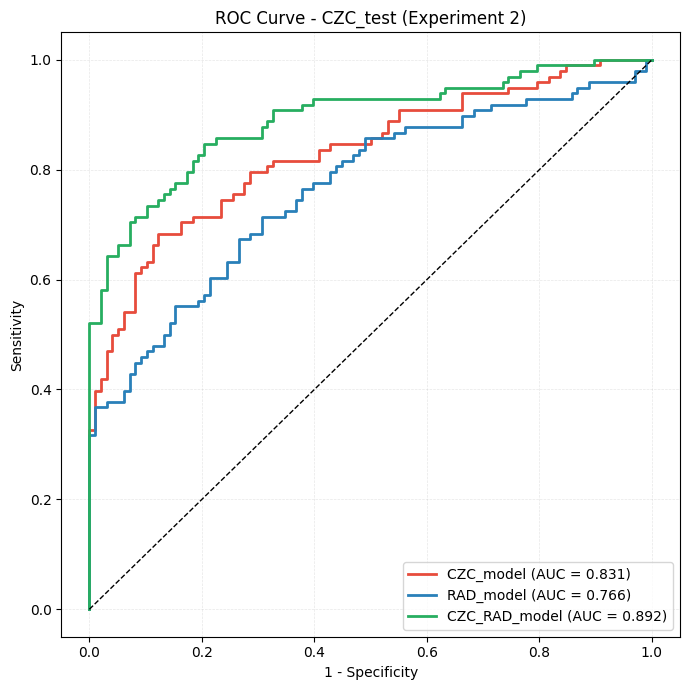

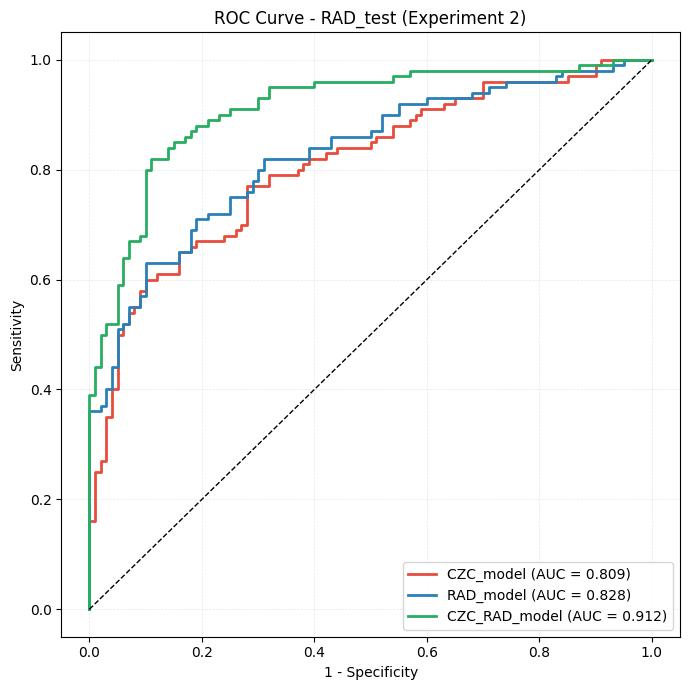

,Evaluation_name,cut_off_threshold_point,tn,fp,fn,tp,sensitivity,specificity,PPV,NPV,F1_score,accuracy,ROC_AUC,CI_90_lower,CI_90_upper,CI_95_lower,CI_95_upper,CI_99_lower,CI_99_upper
0,CZC_model_on_CZC_test,0.7428,86,12,31,67,0.6837,0.8776,0.8481,0.7350,0.7571,0.7806,0.8309,0.7826,0.8793,0.7733,0.8885,0.7552,0.9066
1,CZC_model_on_RAD_test,0.8967,90,10,40,60,0.6000,0.9000,0.8571,0.6923,0.7059,0.7500,0.8085,0.7579,0.8591,0.7482,0.8688,0.7292,0.8878
2,RAD_model_on_CZC_test,0.5280,68,30,28,70,0.7143,0.6939,0.7000,0.7083,0.7071,0.7041,0.7655,0.7098,0.8213,0.6991,0.8320,0.6782,0.8528
3,RAD_model_on_RAD_test,0.7357,90,10,37,63,0.6300,0.9000,0.8630,0.7087,0.7283,0.7650,0.8279,0.7797,0.8761,0.7704,0.8854,0.7524,0.9034
4,CZC_RAD_model_on_CZC_test,0.1783,78,20,15,83,0.8469,0.7959,0.8058,0.8387,0.8259,0.8214,0.8916,0.8525,0.9307,0.8450,0.9382,0.8303,0.9529
5,CZC_RAD_model_on_RAD_test,0.5493,89,11,18,82,0.8200,0.8900,0.8817,0.8318,0.8497,0.8550,0.9119,0.8769,0.9469,0.8702,0.9536,0.8572,0.9666


In [12]:
# Base path to save evaluation outputs for Experiment 2
base_save_path = "Evaluation/EXP2"
os.makedirs(base_save_path, exist_ok=True)

# Paths to trained models (kept as provided)
model_paths = {
    "CZC_model": "Models/TC_CZC.h5",
    "RAD_model": "Models/TC_RAD.h5",
    "CZC_RAD_model": "Models/TC_CZC_RAD.h5",
}

# Test subsets (kept as provided)
test_subsets = {
    "CZC_test": "TC_CZC_test",
    "RAD_test": "TC_RAD_test",
}

# Base path to the cropped test subsets
subsets_path = "Subsets/"

# Keep the same ROC colors as in the original code
model_colors = {
    "CZC_model": "#e74c3c",
    "RAD_model": "#2980b9",
    "CZC_RAD_model": "#27ae60",
}


def auc_confidence_interval(y_true, y_score):
    """
    Compute the AUC and its confidence intervals using the method of
    Hanley & McNeil for binormal ROC curves.

    Parameters
    ----------
    y_true : array-like
        Binary ground-truth labels (0/1).
    y_score : array-like
        Predicted probabilities or continuous scores.

    Returns
    -------
    auc : float
        Area under the ROC curve.
    ci : dict
        Dictionary with lower and upper bounds for 90%, 95% and 99% CIs.
    """
    auc = roc_auc_score(y_true, y_score)
    n1 = sum(y_true)
    n2 = len(y_true) - n1
    q1 = auc / (2 - auc)
    q2 = 2 * auc**2 / (1 + auc)
    se_auc = np.sqrt(
        (auc * (1 - auc) +
         (n1 - 1) * (q1 - auc**2) +
         (n2 - 1) * (q2 - auc**2)) / (n1 * n2)
    )

    z = {0.90: 1.6449, 0.95: 1.96, 0.99: 2.5758}
    ci = {}
    for level in z:
        delta = z[level] * se_auc
        ci[f"CI {int(level * 100)}% lower"] = max(0, auc - delta)
        ci[f"CI {int(level * 100)}% upper"] = min(1, auc + delta)
    return auc, ci


def load_images(images_path):
    """
    Load a list of .npy images into a single NumPy array.
    """
    return np.array([np.load(image_path) for image_path in images_path])


def extract_labels(df, images_path):
    """
    Extract labels aligned with image paths using rx_cod as the identifier.
    """
    label_dict = dict(zip(df["rx_cod"], df["label_CalTend"]))
    return np.array([
        label_dict[os.path.splitext(os.path.basename(path))[0]]
        for path in images_path
    ])


# Store ROC curves for later joint plotting (by subset)
roc_curves_by_subset = {k: {} for k in test_subsets.keys()}

# Collect metrics for final summary table
metrics_summary = []

# === Evaluate each model on each workstation test subset ===
for model_key, model_path in model_paths.items():
    model = load_model(model_path)

    for subset_alias, subset_name in test_subsets.items():
        display_name = f"{model_key} on {subset_alias}"
        print(f"\n=== Evaluation: {display_name} ===")

        # Directory for saving results (kept consistent with other experiments)
        save_dir = os.path.join(base_save_path, f"{model_key}_on_{subset_alias}")
        os.makedirs(save_dir, exist_ok=True)

        # Load subset data
        subset_path = os.path.join(subsets_path, subset_name)
        images_path = [
            os.path.join(subset_path, fname)
            for fname in os.listdir(subset_path)
            if fname.endswith(".npy")
        ]

        X_test = load_images(images_path)
        df_test = pd.read_csv(os.path.join(subsets_path, f"{subset_name}.cropped.csv"))
        y_true = extract_labels(df_test, images_path)

        # Predictions (probabilities)
        y_prob = model.predict(X_test).ravel()

        # ROC curve and Youden threshold (same style as other notebooks)
        fpr, tpr, thresholds = roc_curve(y_true, y_prob)
        youden_index = np.argmax(tpr - fpr)
        best_threshold = thresholds[youden_index]

        # Binary predictions using the chosen threshold
        y_pred = (y_prob >= best_threshold).astype(int)

        # Confusion matrix and metrics
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sensitivity = recall_score(y_true, y_pred)
        specificity = tn / (tn + fp) if (tn + fp) else 0
        ppv = precision_score(y_true, y_pred, zero_division=0)
        npv = tn / (tn + fn) if (tn + fn) else 0
        f1 = f1_score(y_true, y_pred, zero_division=0)
        acc = accuracy_score(y_true, y_pred)
        auc, ci_dict = auc_confidence_interval(y_true, y_prob)

        # Print outputs in the same format used in the other notebook
        print(f"Confusion matrix:\n[[{tn} {fp}]\n [{fn} {tp}]]\n")
        print(f"cut_off_threshold_point: {round(best_threshold, 4)}")
        print(f"Sensitivity: {round(sensitivity, 4)}")
        print(f"Specificity: {round(specificity, 4)}")
        print(f"PPV: {round(ppv, 4)}")
        print(f"NPV: {round(npv, 4)}")
        print(f"F1 score: {round(f1, 4)}")
        print(f"Accuracy: {round(acc, 4)}")
        print(f"ROC AUC: {round(auc, 4)}")
        print(f"CI 90%: [{round(ci_dict['CI 90% lower'], 4)} – {round(ci_dict['CI 90% upper'], 4)}]")
        print(f"CI 95%: [{round(ci_dict['CI 95% lower'], 4)} – {round(ci_dict['CI 95% upper'], 4)}]")
        print(f"CI 99%: [{round(ci_dict['CI 99% lower'], 4)} – {round(ci_dict['CI 99% upper'], 4)}]")

        # Store ROC curve for later joint plots (per subset)
        roc_curves_by_subset[subset_alias][model_key] = (fpr, tpr, auc)

        # ROC curve (per evaluation)
        plt.figure()
        plt.plot(fpr, tpr, color=model_colors[model_key], label=f"AUC = {auc:.3f}")
        plt.plot([0, 1], [0, 1], "k--")
        plt.xlabel("1 - Specificity")
        plt.ylabel("Sensitivity")
        plt.title(f"ROC Curve - {display_name}")
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, "ROC.png"), bbox_inches="tight", dpi=300)
        plt.close()

        # Metrics DataFrame (for this evaluation)
        df_metrics = pd.DataFrame({
            "Evaluation_name": [f"{model_key}_on_{subset_alias}"],
            "cut_off_threshold_point": [round(best_threshold, 4)],
            "tn": [tn],
            "fp": [fp],
            "fn": [fn],
            "tp": [tp],
            "sensitivity": [round(sensitivity, 4)],
            "specificity": [round(specificity, 4)],
            "PPV": [round(ppv, 4)],
            "NPV": [round(npv, 4)],
            "F1 score": [round(f1, 4)],
            "accuracy": [round(acc, 4)],
            "ROC AUC": [round(auc, 4)],
            "CI 90% lower": [round(ci_dict["CI 90% lower"], 4)],
            "CI 90% upper": [round(ci_dict["CI 90% upper"], 4)],
            "CI 95% lower": [round(ci_dict["CI 95% lower"], 4)],
            "CI 95% upper": [round(ci_dict["CI 95% upper"], 4)],
            "CI 99% lower": [round(ci_dict["CI 99% lower"], 4)],
            "CI 99% upper": [round(ci_dict["CI 99% upper"], 4)],
            "y_true": [list(y_true)],
            "y_pred_prob": [list(y_prob)],
        })
        df_metrics.to_csv(os.path.join(save_dir, "metrics.csv"), index=False)

        # Add row to summary list
        metrics_summary.append({
            "Evaluation_name": f"{model_key}_on_{subset_alias}",
            "cut_off_threshold_point": round(best_threshold, 4),
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
            "sensitivity": round(sensitivity, 4),
            "specificity": round(specificity, 4),
            "PPV": round(ppv, 4),
            "NPV": round(npv, 4),
            "F1_score": round(f1, 4),
            "accuracy": round(acc, 4),
            "ROC_AUC": round(auc, 4),
            "CI_90_lower": round(ci_dict["CI 90% lower"], 4),
            "CI_90_upper": round(ci_dict["CI 90% upper"], 4),
            "CI_95_lower": round(ci_dict["CI 95% lower"], 4),
            "CI_95_upper": round(ci_dict["CI 95% upper"], 4),
            "CI_99_lower": round(ci_dict["CI 99% lower"], 4),
            "CI_99_upper": round(ci_dict["CI 99% upper"], 4),
        })


# === Joint ROC per subset (CZC_test and RAD_test) ===
for subset_alias in test_subsets.keys():
    plt.figure(figsize=(7, 7))

    for model_key, (fpr, tpr, auc_val) in roc_curves_by_subset[subset_alias].items():
        plt.plot(
            fpr, tpr,
            label=f"{model_key} (AUC = {auc_val:.3f})",
            color=model_colors[model_key],
            linewidth=2,
        )

    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlabel("1 - Specificity")
    plt.ylabel("Sensitivity")
    plt.title(f"ROC Curve - {subset_alias} (Experiment 2)")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_visible(True)
    plt.legend(loc="lower right", frameon=True)
    plt.tight_layout()
    plt.savefig(
        os.path.join(base_save_path, f"ROC_combined_{subset_alias}.png"),
        bbox_inches="tight",
        dpi=300,
    )
    plt.show()
    plt.close()


# === Final summary table of all evaluations ===
metrics_df_summary = pd.DataFrame(metrics_summary)
metrics_df_summary.to_csv(
    os.path.join(base_save_path, "summary_all_models_on_RAD_CZC_test.csv"),
    index=False,
)

metrics_df_summary


#### **5.2. Statistical comparison between models (DeLong for AUC, McNemar for paired errors)**

In [30]:
# === Build a joint DataFrame with aligned cases (Experiment 2) ===
ID_COL = "rx_cod"

def build_joint_eval_df(
    image_paths,
    y_true,
    pred_dict,
    id_col=ID_COL,
):
    ids = [os.path.splitext(os.path.basename(p))[0] for p in image_paths]

    df_joint = pd.DataFrame({
        id_col: ids,
        "label": np.asarray(y_true).ravel(),
    })

    for model_name, y_prob in pred_dict.items():
        df_joint[f"y_pred_prob_{model_name}"] = np.asarray(y_prob).ravel()

    return df_joint


# CZC test set (aligned)
df_joint_czc = build_joint_eval_df(
    image_paths=images_test_path_CZC,
    y_true=y_test_CZC,
    pred_dict={
        "CZC_model": preds_CZC_on_CZC,
        "RAD_model": preds_RAD_on_CZC,
        "CZC_RAD_model": preds_CZC_RAD_on_CZC,
    },
)

# RAD test set (aligned)
df_joint_rad = build_joint_eval_df(
    image_paths=images_test_path_RAD,
    y_true=y_test_RAD,
    pred_dict={
        "CZC_model": preds_CZC_on_RAD,
        "RAD_model": preds_RAD_on_RAD,
        "CZC_RAD_model": preds_CZC_RAD_on_RAD,
    },
)

print(f"Aligned cases (CZC_test): {df_joint_czc.shape[0]}")
print(f"Aligned cases (RAD_test): {df_joint_rad.shape[0]}")


Aligned cases (CZC_test): 196
Aligned cases (RAD_test): 200


In [33]:
# === DeLong test for paired ROC AUC comparison ===

def _compute_midrank(x):
    """Compute midranks for ties."""
    sorted_idx = np.argsort(x)
    sorted_x = x[sorted_idx]
    N = len(x)
    midranks = np.zeros(N, dtype=float)

    i = 0
    while i < N:
        j = i
        while j < N and sorted_x[j] == sorted_x[i]:
            j += 1
        midrank = 0.5 * (i + j - 1) + 1
        midranks[i:j] = midrank
        i = j

    out = np.empty(N, dtype=float)
    out[sorted_idx] = midranks
    return out


def _fast_delong(predictions, labels):
    """
    Fast DeLong implementation for AUC variance (paired).

    IMPORTANT:
    This implementation requires reordering samples so that positives come first.
    """
    labels = labels.astype(int)

    # Reorder so that positives are first, negatives are last
    order = np.argsort(-labels)  # 1s first, then 0s
    labels = labels[order]
    predictions = predictions[:, order]

    pos = labels == 1
    neg = labels == 0

    m = np.sum(pos)
    n = np.sum(neg)

    preds_pos = predictions[:, :m]
    preds_neg = predictions[:, m:]

    k = predictions.shape[0]

    tx = np.empty((k, m))
    ty = np.empty((k, n))
    tz = np.empty((k, m + n))

    for r in range(k):
        tx[r] = _compute_midrank(preds_pos[r])
        ty[r] = _compute_midrank(preds_neg[r])
        tz[r] = _compute_midrank(predictions[r])

    aucs = (tz[:, :m].sum(axis=1) - m * (m + 1) / 2) / (m * n)

    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m

    sx = np.cov(v01)
    sy = np.cov(v10)

    return aucs, sx / m + sy / n


def delong_roc_test(y_true, pred_model_1, pred_model_2):
    """
    Paired DeLong test for ROC AUC comparison.

    Returns
    -------
    dict with keys:
    - auc1, auc2
    - delta_auc
    - z_score
    - p_value
    """
    y_true = np.asarray(y_true)
    preds = np.vstack([
        np.asarray(pred_model_1),
        np.asarray(pred_model_2)
    ])

    aucs, cov = _fast_delong(preds, y_true)
    auc1, auc2 = aucs
    delta_auc = auc1 - auc2

    var = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    z = delta_auc / np.sqrt(var)
    p_value = 2 * (1 - norm.cdf(abs(z)))

    return {
        "auc1": auc1,
        "auc2": auc2,
        "delta_auc": delta_auc,
        "z_score": z,
        "p_value": p_value,
    }

# === DeLong test for paired ROC AUC comparison (3 models) ===

def run_pairwise_delong(df_joint, subset_name, alpha=0.05):
    y_true = df_joint["label"].values

    pairs = [
        ("CZC_model", "RAD_model"),
        ("CZC_model", "CZC_RAD_model"),
        ("RAD_model", "CZC_RAD_model"),
    ]

    print(f"\n=== DeLong tests (paired AUC) — {subset_name} ===")

    results = []
    for m1, m2 in pairs:
        y1 = df_joint[f"y_pred_prob_{m1}"].values
        y2 = df_joint[f"y_pred_prob_{m2}"].values

        res = delong_roc_test(y_true=y_true, pred_model_1=y1, pred_model_2=y2)

        print(f"\nComparison: {m1} vs {m2}")
        print(f"AUC {m1}: {res['auc1']:.4f}")
        print(f"AUC {m2}: {res['auc2']:.4f}")
        print(f"Delta AUC ({m1} - {m2}): {res['delta_auc']:.4f}")
        print(f"Z-score: {res['z_score']:.4f}")
        print(f"P-value (two-sided): {res['p_value']:.4e}")

        results.append((m1, m2, res["p_value"], res["delta_auc"]))

    # Minimal multiple-comparison note (3 pairwise tests)
    print("\nNote:")
    print(
        "- Three pairwise AUC comparisons are performed. If you want strict control of "
        "family-wise error, consider adjusting p-values (e.g., Holm correction)."
    )

    return results


_ = run_pairwise_delong(df_joint_czc, subset_name="CZC_test")
_ = run_pairwise_delong(df_joint_rad, subset_name="RAD_test")



=== DeLong tests (paired AUC) — CZC_test ===

Comparison: CZC_model vs RAD_model
AUC CZC_model: 0.8309
AUC RAD_model: 0.7655
Delta AUC (CZC_model - RAD_model): 0.0654
Z-score: 2.0986
P-value (two-sided): 3.5848e-02

Comparison: CZC_model vs CZC_RAD_model
AUC CZC_model: 0.8309
AUC CZC_RAD_model: 0.8916
Delta AUC (CZC_model - CZC_RAD_model): -0.0607
Z-score: -2.6036
P-value (two-sided): 9.2241e-03

Comparison: RAD_model vs CZC_RAD_model
AUC RAD_model: 0.7655
AUC CZC_RAD_model: 0.8916
Delta AUC (RAD_model - CZC_RAD_model): -0.1261
Z-score: -4.0800
P-value (two-sided): 4.5034e-05

Note:
- Three pairwise AUC comparisons are performed. If you want strict control of family-wise error, consider adjusting p-values (e.g., Holm correction).

=== DeLong tests (paired AUC) — RAD_test ===

Comparison: CZC_model vs RAD_model
AUC CZC_model: 0.8085
AUC RAD_model: 0.8279
Delta AUC (CZC_model - RAD_model): -0.0194
Z-score: -0.5932
P-value (two-sided): 5.5304e-01

Comparison: CZC_model vs CZC_RAD_model
A

In [34]:
# === Automatic interpretation of DeLong test results ===

def interpret_delong_results(df_joint, subset_name, alpha=0.05):
    y_true = df_joint["label"].values

    comparisons = [
        ("CZC_model", "RAD_model"),
        ("CZC_model", "CZC_RAD_model"),
        ("RAD_model", "CZC_RAD_model"),
    ]

    print(f"\n=== Interpretation of DeLong tests — {subset_name} ===")

    for m1, m2 in comparisons:
        y1 = df_joint[f"y_pred_prob_{m1}"].values
        y2 = df_joint[f"y_pred_prob_{m2}"].values

        res = delong_roc_test(y_true=y_true, pred_model_1=y1, pred_model_2=y2)

        auc1, auc2 = res["auc1"], res["auc2"]
        delta = res["delta_auc"]
        p = res["p_value"]

        if p < alpha:
            if delta > 0:
                conclusion = (
                    f"{m1} shows a statistically significantly higher AUC than {m2}"
                )
            else:
                conclusion = (
                    f"{m2} shows a statistically significantly higher AUC than {m1}"
                )
        else:
            conclusion = (
                f"No statistically significant difference in AUC is observed "
                f"between {m1} and {m2}"
            )

        print(
            f"- {m1} vs {m2}: "
            f"AUCs = {auc1:.3f} vs {auc2:.3f}, "
            f"ΔAUC = {delta:.3f}, p = {p:.3e} → {conclusion}."
        )


# Run interpretation
interpret_delong_results(df_joint_czc, subset_name="CZC_test")
interpret_delong_results(df_joint_rad, subset_name="RAD_test")



=== Interpretation of DeLong tests — CZC_test ===
- CZC_model vs RAD_model: AUCs = 0.831 vs 0.766, ΔAUC = 0.065, p = 3.585e-02 → CZC_model shows a statistically significantly higher AUC than RAD_model.
- CZC_model vs CZC_RAD_model: AUCs = 0.831 vs 0.892, ΔAUC = -0.061, p = 9.224e-03 → CZC_RAD_model shows a statistically significantly higher AUC than CZC_model.
- RAD_model vs CZC_RAD_model: AUCs = 0.766 vs 0.892, ΔAUC = -0.126, p = 4.503e-05 → CZC_RAD_model shows a statistically significantly higher AUC than RAD_model.

=== Interpretation of DeLong tests — RAD_test ===
- CZC_model vs RAD_model: AUCs = 0.808 vs 0.828, ΔAUC = -0.019, p = 5.530e-01 → No statistically significant difference in AUC is observed between CZC_model and RAD_model.
- CZC_model vs CZC_RAD_model: AUCs = 0.808 vs 0.912, ΔAUC = -0.103, p = 6.782e-05 → CZC_RAD_model shows a statistically significantly higher AUC than CZC_model.
- RAD_model vs CZC_RAD_model: AUCs = 0.828 vs 0.912, ΔAUC = -0.084, p = 1.048e-03 → CZC_RAD

### **6. Grad-CAM Visualization**

In [13]:
# === Generate predictions on the CZC test set ===
preds_CZC_on_CZC = model_CZC.predict(X_test_CZC, verbose=1).flatten()
preds_RAD_on_CZC = model_RAD.predict(X_test_CZC, verbose=1).flatten()
preds_CZC_RAD_on_CZC = model_CZC_RAD.predict(X_test_CZC, verbose=1).flatten()

# === Generate predictions on the RAD test set ===
preds_RAD_on_RAD = model_RAD.predict(X_test_RAD, verbose=1).flatten()
preds_CZC_on_RAD = model_CZC.predict(X_test_RAD, verbose=1).flatten()
preds_CZC_RAD_on_RAD = model_CZC_RAD.predict(X_test_RAD, verbose=1).flatten()

# === Sanity check: display prediction shapes ===
print(f"preds_CZC_on_CZC shape: {preds_CZC_on_CZC.shape}")
print(f"preds_RAD_on_CZC shape: {preds_RAD_on_CZC.shape}")
print(f"preds_CZC_RAD_on_CZC shape: {preds_CZC_RAD_on_CZC.shape}")

print(f"preds_RAD_on_RAD shape: {preds_RAD_on_RAD.shape}")
print(f"preds_CZC_on_RAD shape: {preds_CZC_on_RAD.shape}")
print(f"preds_CZC_RAD_on_RAD shape: {preds_CZC_RAD_on_RAD.shape}")


7/7 [==============================] - 2s 274ms/step
preds_CZC_on_CZC shape: (196,)
preds_RAD_on_CZC shape: (196,)
preds_CZC_RAD_on_CZC shape: (196,)
preds_RAD_on_RAD shape: (200,)
preds_CZC_on_RAD shape: (200,)
preds_CZC_RAD_on_RAD shape: (200,)


In [15]:
# === Grad-CAM heatmap generation ===
def generate_gradcam_heatmaps(
    model,
    X_images_array,
    y_labels,
    predictions,
    last_conv_layer_name,
    model_type,
    classifier_layer_names=None,
    show=False,
):
    if classifier_layer_names is None:
        classifier_layer_names = []

    heatmaps_imgs = []

    for idx, img in enumerate(X_images_array):
        img_array_4d = np.expand_dims(img, axis=0)
        original_image = (img * 255).astype("uint8")

        # --- Convolutional model ---
        if model_type == 2:
            base_model = model.get_layer(last_conv_layer_name)
            conv_output = base_model.output
            conv_model = tf.keras.Model(base_model.input, conv_output)
        else:
            conv_output = model.get_layer(last_conv_layer_name).output
            conv_model = tf.keras.Model(model.input, conv_output)

        # --- Classifier model ---
        classifier_input = tf.keras.Input(shape=conv_model.output.shape[1:])
        x = classifier_input

        if model_type == 1:
            for layer_name in classifier_layer_names:
                x = model.get_layer(layer_name)(x)
        elif model_type == 2:
            for layer in model.layers[1:]:
                x = layer(x)
        elif model_type == 3:
            top_model = model.get_layer(classifier_layer_names)
            for layer in top_model.layers:
                x = layer(x)

        classifier_model = tf.keras.Model(classifier_input, x)

        # --- Gradients ---
        with tf.GradientTape() as tape:
            conv_output_vals = conv_model(img_array_4d)
            tape.watch(conv_output_vals)
            preds = classifier_model(conv_output_vals)
            class_channel = preds[:, 0]

        grads = tape.gradient(class_channel, conv_output_vals)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_output_vals = conv_output_vals.numpy()[0]

        for i in range(pooled_grads.shape[-1]):
            conv_output_vals[:, :, i] *= pooled_grads[i].numpy()

        heatmap = np.mean(conv_output_vals, axis=-1)
        heatmap = np.maximum(heatmap, 0) / (np.max(heatmap) + 1e-10)
        heatmap = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
        heatmap = np.uint8(255 * (1.0 - heatmap))
        heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        superimposed = cv2.addWeighted(heatmap_color, 0.4, original_image, 1.0, 0)

        heatmaps_imgs.append(superimposed)

        if show:
            plt.imshow(superimposed)
            plt.title(
                f"X-ray {idx} - True: {y_labels[idx]} - Pred: {predictions[idx]:.3f}"
            )
            plt.axis("off")
            plt.show()

    return heatmaps_imgs


In [16]:
# === Heatmap visualization (original image + 3 model heatmaps) ===
def visualize_heatmaps_4col(
    X_images_array,
    y_true,
    preds_dict,
    heatmaps_dict,
    rx_indices,
    subset_name,
    image_paths=None,
):
    """
    Visualize one original image plus three Grad-CAM heatmaps (one per model),
    arranged in 4 columns for a list of image indices.
    """
    model_order = ["CZC", "RAD", "CZC_RAD"]
    model_titles = {
        "CZC": "CZC model",
        "RAD": "RAD model",
        "CZC_RAD": "CZC+RAD model",
    }

    num_cols = 4
    fig, axes = plt.subplots(
        len(rx_indices),
        num_cols,
        figsize=(4 * num_cols, 4 * len(rx_indices)),
    )

    if len(rx_indices) == 1:
        axes = [axes]

    for i, rx_idx in enumerate(rx_indices):
        rx_cod = (
            os.path.splitext(os.path.basename(image_paths[rx_idx]))[0]
            if image_paths
            else f"IDX_{rx_idx}"
        )

        # Column 1: original X-ray
        ax_img = axes[i][0]
        ax_img.imshow(X_images_array[rx_idx], cmap="gray")
        ax_img.set_title(f"Original X-ray\n[{subset_name}]\n{rx_cod}")
        ax_img.axis("off")

        # Columns 2–4: Grad-CAM heatmaps
        for j, model_key in enumerate(model_order):
            ax = axes[i][j + 1]
            heatmap = heatmaps_dict[model_key][rx_idx]
            pred = preds_dict[model_key][rx_idx]
            true = y_true[rx_idx]
            pred_label = int(pred >= 0.5)
            is_correct = pred_label == true

            ax.imshow(heatmap)
            ax.set_title(
                f"{model_titles[model_key]}\n"
                f"{'Correct' if is_correct else 'Error'} "
                f"Pred:{pred_label} True:{true}\n"
                f"Prob: {min(pred, 0.999):.3f}"
            )
            ax.axis("off")

            for spine in ax.spines.values():
                spine.set_edgecolor("green" if is_correct else "red")
                spine.set_linewidth(4)

    plt.tight_layout()
    plt.show()


In [17]:
# === Generate Grad-CAM heatmaps on the CZC test set ===
print("Generating Grad-CAM heatmaps for CZC model on CZC test set...")
heatmaps_CZC_on_CZC = generate_gradcam_heatmaps(
    model=model_CZC,
    X_images_array=X_test_CZC,
    y_labels=y_test_CZC,
    predictions=preds_CZC_on_CZC,
    last_conv_layer_name="vgg19",
    model_type=2,
    classifier_layer_names=[],
    show=False,
)

print("Generating Grad-CAM heatmaps for RAD model on CZC test set...")
heatmaps_RAD_on_CZC = generate_gradcam_heatmaps(
    model=model_RAD,
    X_images_array=X_test_CZC,
    y_labels=y_test_CZC,
    predictions=preds_RAD_on_CZC,
    last_conv_layer_name="vgg19",
    model_type=2,
    classifier_layer_names=[],
    show=False,
)

print("Generating Grad-CAM heatmaps for CZC+RAD model on CZC test set...")
heatmaps_CZC_RAD_on_CZC = generate_gradcam_heatmaps(
    model=model_CZC_RAD,
    X_images_array=X_test_CZC,
    y_labels=y_test_CZC,
    predictions=preds_CZC_RAD_on_CZC,
    last_conv_layer_name="vgg19",
    model_type=2,
    classifier_layer_names=[],
    show=False,
)

# === Generate Grad-CAM heatmaps on the RAD test set ===
print("Generating Grad-CAM heatmaps for RAD model on RAD test set...")
heatmaps_RAD_on_RAD = generate_gradcam_heatmaps(
    model=model_RAD,
    X_images_array=X_test_RAD,
    y_labels=y_test_RAD,
    predictions=preds_RAD_on_RAD,
    last_conv_layer_name="vgg19",
    model_type=2,
    classifier_layer_names=[],
    show=False,
)

print("Generating Grad-CAM heatmaps for CZC model on RAD test set...")
heatmaps_CZC_on_RAD = generate_gradcam_heatmaps(
    model=model_CZC,
    X_images_array=X_test_RAD,
    y_labels=y_test_RAD,
    predictions=preds_CZC_on_RAD,
    last_conv_layer_name="vgg19",
    model_type=2,
    classifier_layer_names=[],
    show=False,
)

print("Generating Grad-CAM heatmaps for CZC+RAD model on RAD test set...")
heatmaps_CZC_RAD_on_RAD = generate_gradcam_heatmaps(
    model=model_CZC_RAD,
    X_images_array=X_test_RAD,
    y_labels=y_test_RAD,
    predictions=preds_CZC_RAD_on_RAD,
    last_conv_layer_name="vgg19",
    model_type=2,
    classifier_layer_names=[],
    show=False,
)

print("Grad-CAM heatmaps generated for all models.")


Generating Grad-CAM heatmaps for CZC model on CZC test set...
Generating Grad-CAM heatmaps for RAD model on CZC test set...
Generating Grad-CAM heatmaps for CZC+RAD model on CZC test set...
Generating Grad-CAM heatmaps for RAD model on RAD test set...
Generating Grad-CAM heatmaps for CZC model on RAD test set...
Generating Grad-CAM heatmaps for CZC+RAD model on RAD test set...
Grad-CAM heatmaps generated for all models.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.056796603..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05664664..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09257291..0.99731076].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.051115014..1.0].


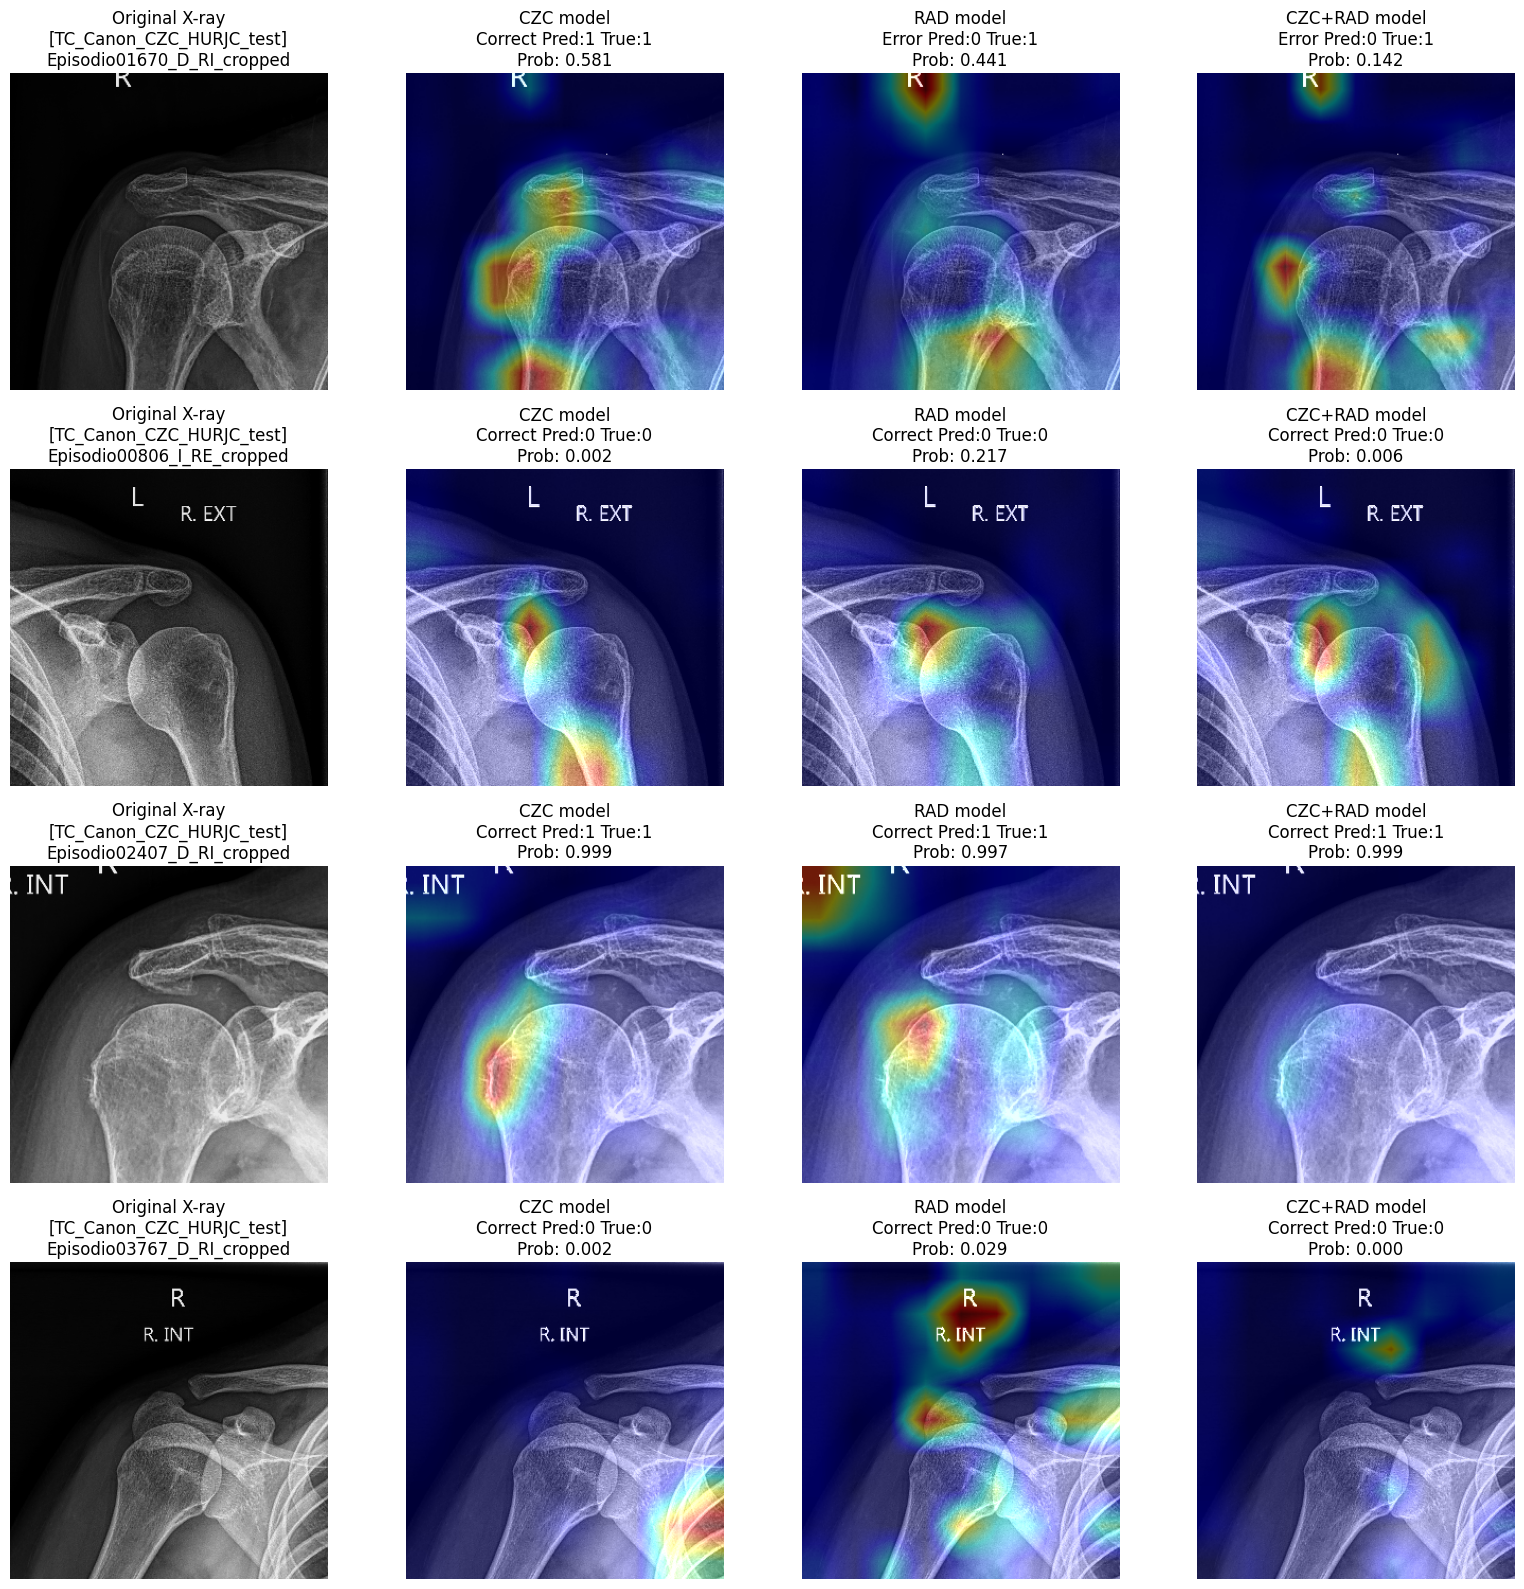

In [18]:
# === Example: visualize heatmaps on the CZC test set ===
visualize_heatmaps_4col(
    X_images_array=X_test_CZC,
    y_true=y_test_CZC,
    preds_dict={
        "CZC": preds_CZC_on_CZC,
        "RAD": preds_RAD_on_CZC,
        "CZC_RAD": preds_CZC_RAD_on_CZC,
    },
    heatmaps_dict={
        "CZC": heatmaps_CZC_on_CZC,
        "RAD": heatmaps_RAD_on_CZC,
        "CZC_RAD": heatmaps_CZC_RAD_on_CZC,
    },
    rx_indices=list(range(0, 4)),
    subset_name="TC_CZC_HURJC_test",
    image_paths=images_test_path_CZC,
)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.114196576..0.95141304].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0037007954..0.94600856].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.020321466..0.99460715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.011915645..0.9611078].


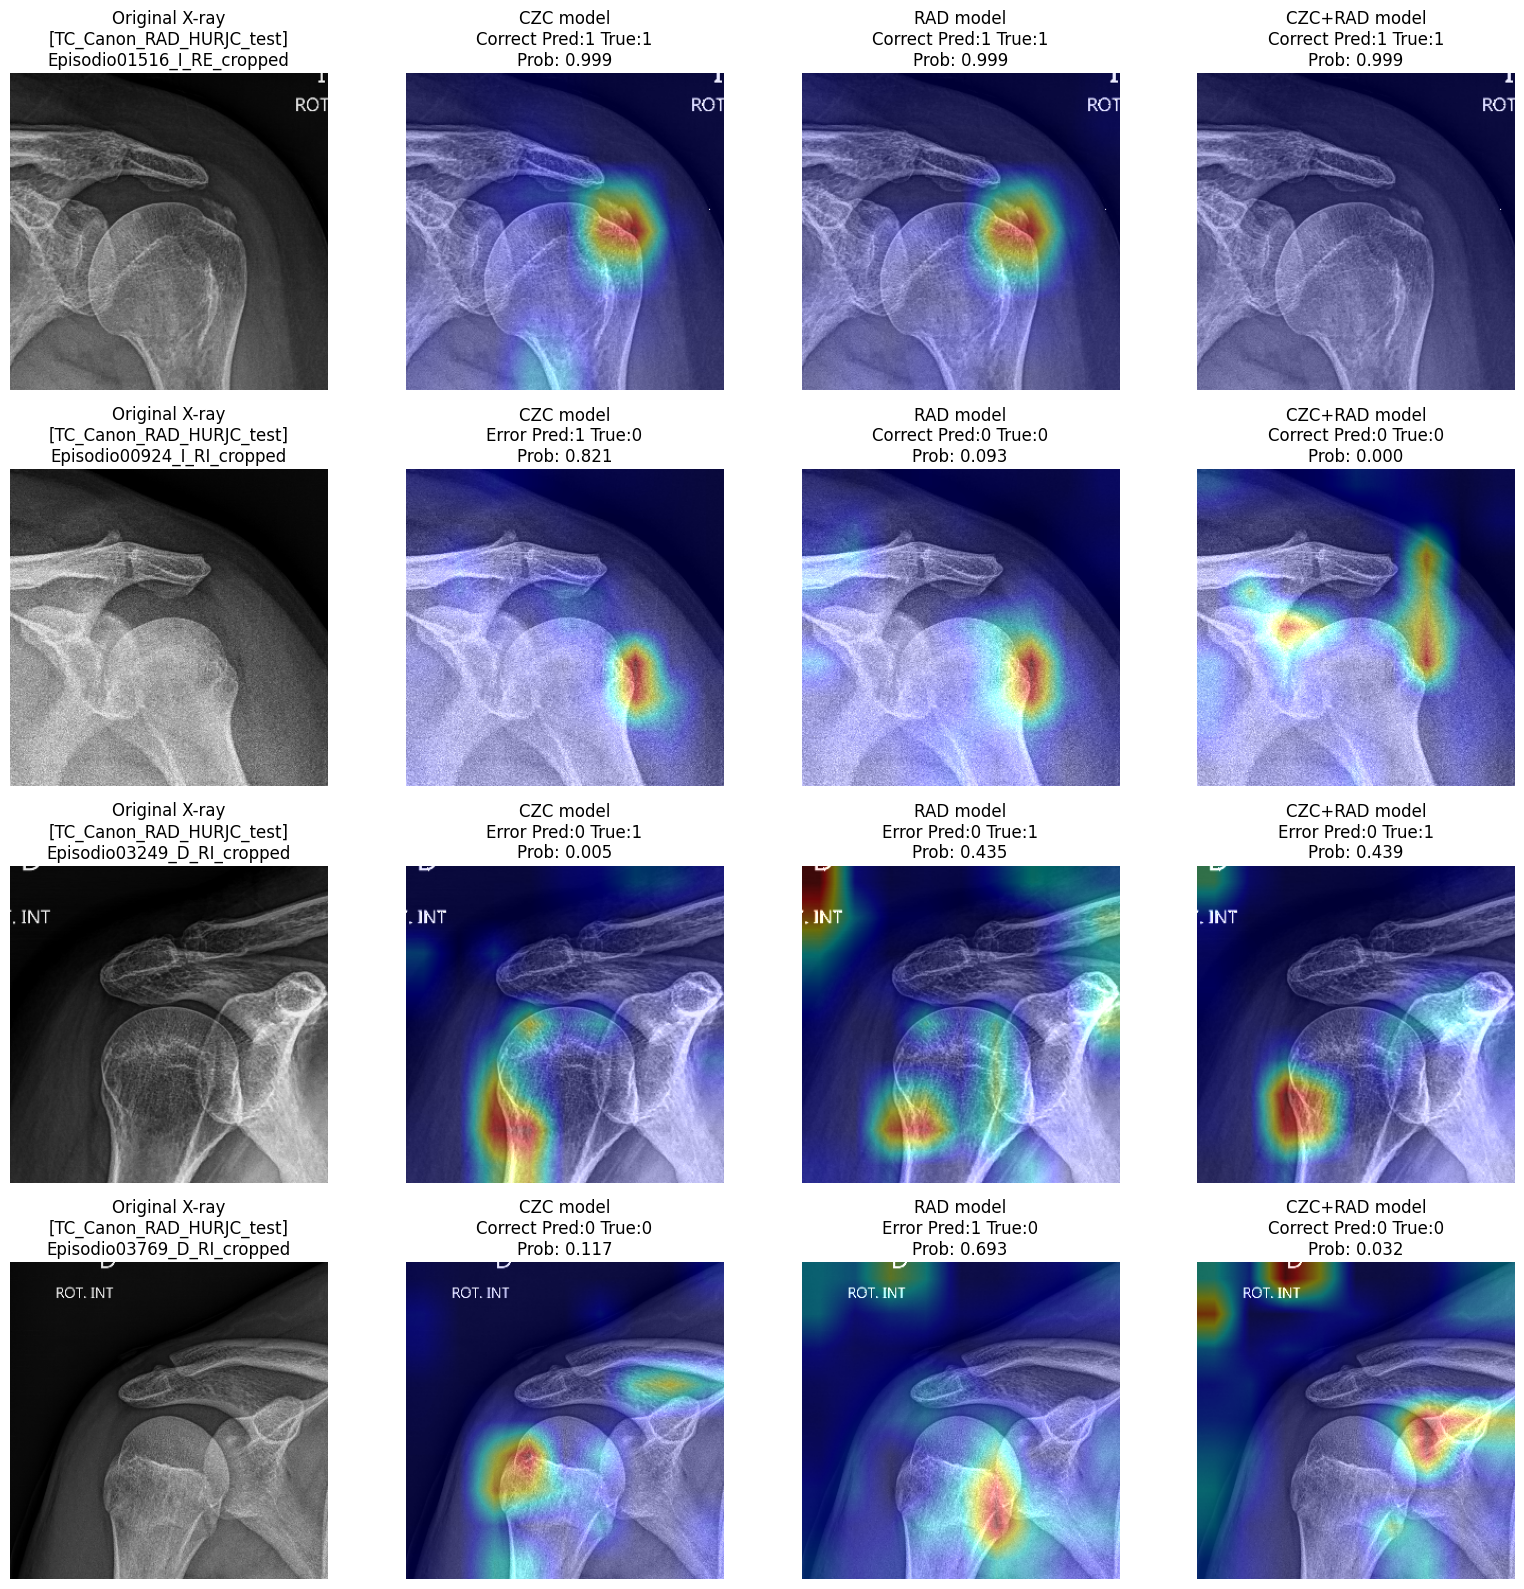

In [19]:
# === Example: visualize heatmaps on the RAD test set ===

visualize_heatmaps_4col(
    X_images_array=X_test_RAD,
    y_true=y_test_RAD,
    preds_dict={
        'CZC': preds_CZC_on_RAD,
        'RAD': preds_RAD_on_RAD,
        'CZC_RAD': preds_CZC_RAD_on_RAD
    },
    heatmaps_dict={
        'CZC': heatmaps_CZC_on_RAD,
        'RAD': heatmaps_RAD_on_RAD,
        'CZC_RAD': heatmaps_CZC_RAD_on_RAD
    },
    rx_indices=list(range(0, 4)),
    subset_name='TC_RAD_HURJC_test',
    image_paths=images_test_path_RAD
)


### **7. Sumary and Conclusions**

The results of Experiment 2 clearly confirm that the workstation used for radiograph processing has a significant impact on the generalization performance of deep learning models. Models trained on a single workstation domain achieved acceptable performance when evaluated on images from the same domain, but their performance degraded when tested on images processed by a different workstation. This behavior is consistent with a distribution shift driven by textural differences introduced during image processing, which alters the internal representations learned by the network.

This effect is evident in the asymmetric cross-domain results observed for the CZC-only and RAD-only models. Each model performed best on its native test set, with AUC values around 0.83, but showed reduced sensitivity or specificity when applied to the opposite domain. In contrast, the combined CZC+RAD model demonstrated more robust and consistent performance across both test sets, achieving higher AUC values (approximately 0.89 on CZC and 0.91 on RAD) and improved balance between sensitivity and specificity. These findings indicate that exposure to heterogeneous technical domains during training leads to more flexible and generalizable feature representations.

Qualitative analysis using Grad-CAM heatmaps further supports these conclusions. Across models and test domains, activation maps generally focused on anatomically and pathologically relevant regions, even in cases of incorrect predictions. This suggests that the networks learned where to attend within the image, but that decision-level discrimination was compromised under distribution shift. Overall, Experiment 2 highlights that diagnostic robustness in medical imaging depends not only on dataset size, but also on technical diversity. For reliable clinical deployment, training datasets should include images from multiple workstations or technical domains to ensure stable performance under real-world variability.
